In [ ]:
from sqlalchemy import create_engine
import pandas as pd
import os
import psycopg2
from google.colab import drive
from datetime import datetime
from datetime import timedelta
from tqdm.auto import trange
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from tqdm import trange

In [ ]:
tax_engine = create_engine(f"postgresql+psycopg2://postgres:pw@hostname:5433/nj_tax_assessor")  # Connection for sqlalchemy to get data
gsmls_engine = create_engine(f"postgresql+psycopg2://postgres:pw@hostname:5433/gsmls")  # Connection for sqlalchemy to get data

In [ ]:
pd.set_option('display.max_columns', 999)

In [ ]:
pd.set_option('display.max_rows', None)

# Load the data from PostgreSQL

In [ ]:
query = f"SELECT * FROM gsmls_imputed_data LIMIT 1;"
test_data = pd.read_sql_query(query, tax_engine)

In [ ]:
test_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1 entries, 0 to 0
Columns: 151 entries, mlsnum to year_built
dtypes: bool(102), datetime64[ns](1), float64(23), int64(10), object(15)
memory usage: 626.0+ bytes


In [ ]:
test_data.columns[:100]

Index(['mlsnum', 'status_short', 'address', 'town', 'county', 'zipcode',
       'nj_towncode', 'towncode', 'countycode', 'blockid', 'lotid', 'taxid',
       'latitude', 'longitude', 'daysonmarket', 'condition', 'mortgage_rate',
       'origlistprice', 'listprice', 'olp_lp', 'salesprice', 'sp_lp',
       'investment_sale', 'potential_investment', 'distressed_sale',
       'short_sale', 'bank_owned', 'rooms', 'beds', 'bathstotal', 'sqftapprox',
       'lotsize_sqft_orig', 'assessamountbldg', 'assessamountland',
       'assesstotal', 'taxamount', 'subproptype_sfh', 'styleprimary_short',
       'qtr', 'month', 'year', 'days_to_close', 'antic_closedate_diff',
       'yearbuilt', 'listdate', 'closeddate', 'easement_short', 'garagecap',
       'fireplaces', 'pool_short', 'appfee', 'assocfee', 'wood_floors',
       'marble_floors', 'tile_floors', 'carpet_floors', 'vinyl_floors',
       'laminate_floors', 'stone_floors', 'parquet_floors', 'off_street_pkng',
       'one_car_wide', 'two_car_wide'

In [ ]:
for i in test_data.columns:
  print(i)

mlsnum
status_short
address
town
county
zipcode
nj_towncode
towncode
countycode
blockid
lotid
taxid
latitude
longitude
daysonmarket
condition
mortgage_rate
origlistprice
listprice
olp_lp
salesprice
sp_lp
investment_sale
potential_investment
distressed_sale
short_sale
bank_owned
rooms
beds
bathstotal
sqftapprox
lotsize_sqft_orig
assessamountbldg
assessamountland
assesstotal
taxamount
subproptype_sfh
styleprimary_short
qtr
month
year
days_to_close
antic_closedate_diff
yearbuilt
listdate
closeddate
easement_short
garagecap
fireplaces
pool_short
appfee
assocfee
wood_floors
marble_floors
tile_floors
carpet_floors
vinyl_floors
laminate_floors
stone_floors
parquet_floors
off_street_pkng
one_car_wide
two_car_wide
window_ac
central_ac
one_unit_ac
two_units_ac
three_units_ac
wall_unit_ac
ceilfan_ac
ductless_ac
multizone_ac
heat_src_natgas
heat_src_electric
heat_src_oilabv
heat_src_oilbel
heat_src_solar
basedesc_bilcosty
basedesc_finished
basedesc_finpart
basedesc_frnchdrn
basedesc_full
basedesc_

## Which counties have had the most/least data collected. Show in the form of a bar chart

In [ ]:
query="""
SELECT county, COUNT(*) as total_properties
FROM  gsmls_imputed_data
GROUP BY county;
"""

total_properties =  pd.read_sql_query(query, tax_engine)

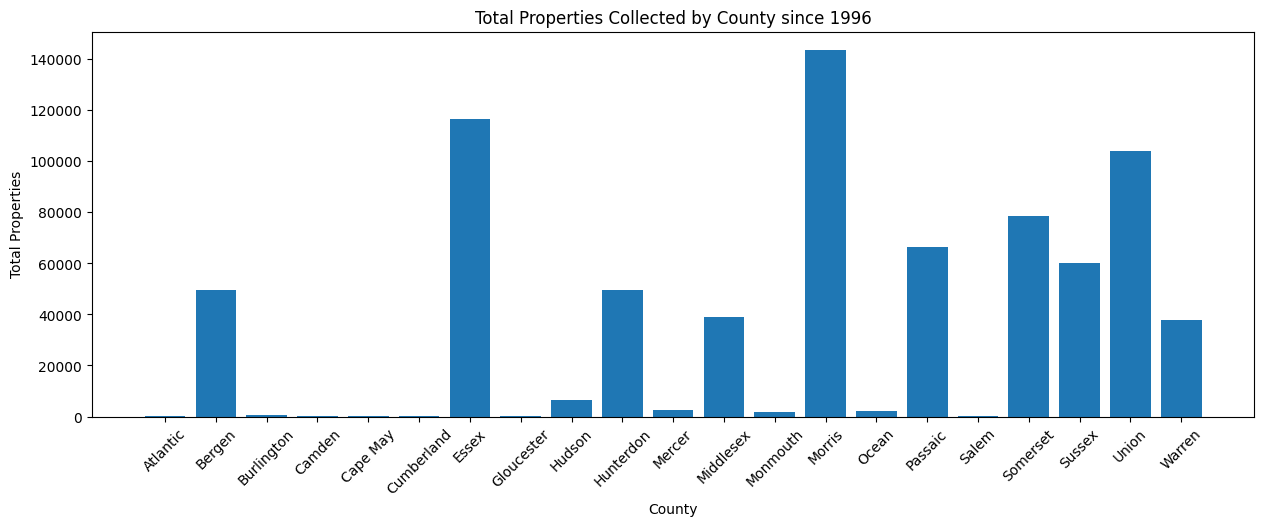

In [ ]:
fig, axs = plt.subplots(figsize=(15,5))

axs.bar('county', 'total_properties', data=total_properties)
axs.set_title('Total Properties Collected by County since 1996')
axs.set_xlabel('County')
plt.xticks(rotation=45)
axs.set_ylabel('Total Properties')

plt.show()

## Calculate the Median Sales Price by Year fo the state of NJ since 1996

In [ ]:
query="""
SELECT gsmls_imputed_data.year, percentile_cont(0.5) WITHIN GROUP(ORDER BY CAST(salesprice as numeric)) as median_sales_price
FROM gsmls_imputed_data
GROUP BY gsmls_imputed_data.year;
"""

med_sales_price = pd.read_sql_query(query, tax_engine)

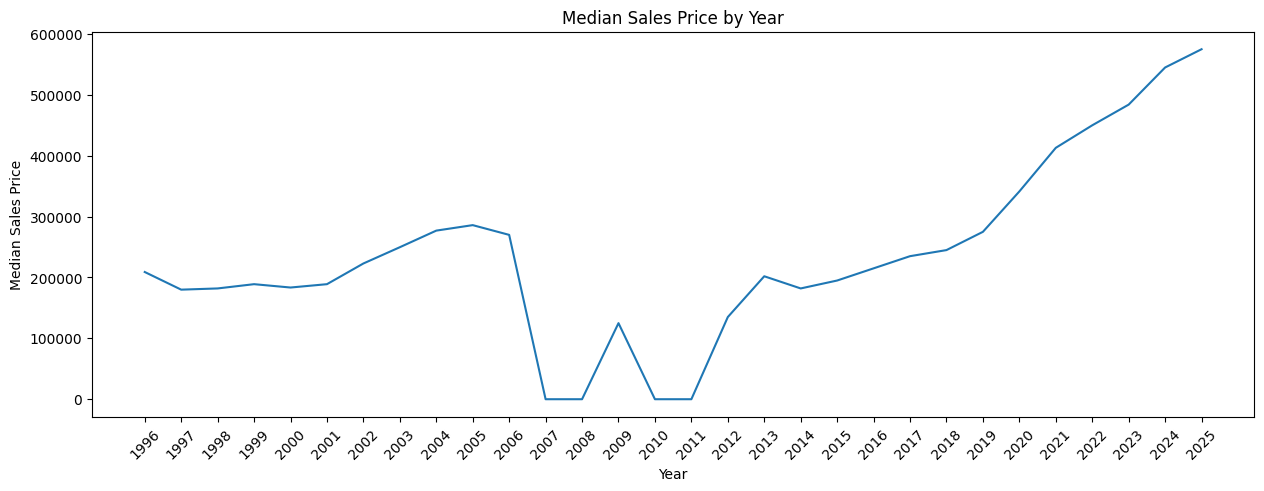

In [ ]:
fig, axs = plt.subplots(figsize=(15, 5))

axs.plot('year', 'median_sales_price', data=med_sales_price)
axs.set_title('Median Sales Price by Year')
axs.set_xlabel('Year')
axs.set_ylabel('Median Sales Price')

plt.xticks(range(1996, 2026, 1), rotation=45)
plt.show()

## Calculate the Median Sales Price by Year fo the state of NJ since 1996  (for counties with sufficient data)

In [ ]:
query="""
SELECT gsmls_imputed_data.year, county, percentile_cont(0.5) WITHIN GROUP(ORDER BY CAST(salesprice as numeric)) as median_sales_price
FROM gsmls_imputed_data
WHERE county IN ('Essex', 'Morris', 'Middlesex', 'Hunterdon', 'Passaic', 'Somerset', 'Sussex' ,'Union', 'Warren')
GROUP BY gsmls_imputed_data.year, county;
"""

med_sales_price = pd.read_sql_query(query, tax_engine)

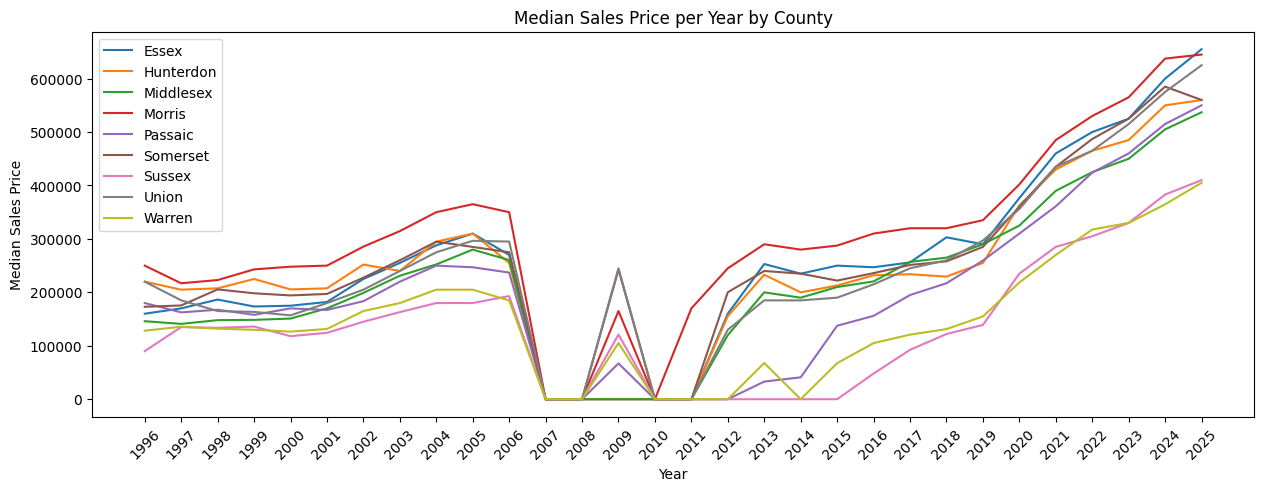

In [ ]:
fig, axs = plt.subplots(figsize=(15, 5))

for county in med_sales_price['county'].unique():
  axs.plot('year', 'median_sales_price', data=med_sales_price[med_sales_price['county'] == county], label=county)

axs.set_title('Median Sales Price per Year by County')
axs.set_xlabel('Year')
axs.set_ylabel('Median Sales Price')

plt.xticks(range(1996, 2026, 1), rotation=45)
plt.legend()
plt.show()

## Plot the average amount of days a property spent on the market. Point out the recessions on the chart

In [ ]:
query="""
SELECT gsmls_imputed_data.year, percentile_cont(0.5) WITHIN GROUP(ORDER BY CAST(daysonmarket as numeric)) as median_dom
FROM gsmls_imputed_data
GROUP BY gsmls_imputed_data.year;
"""

med_dom = pd.read_sql_query(query, tax_engine)

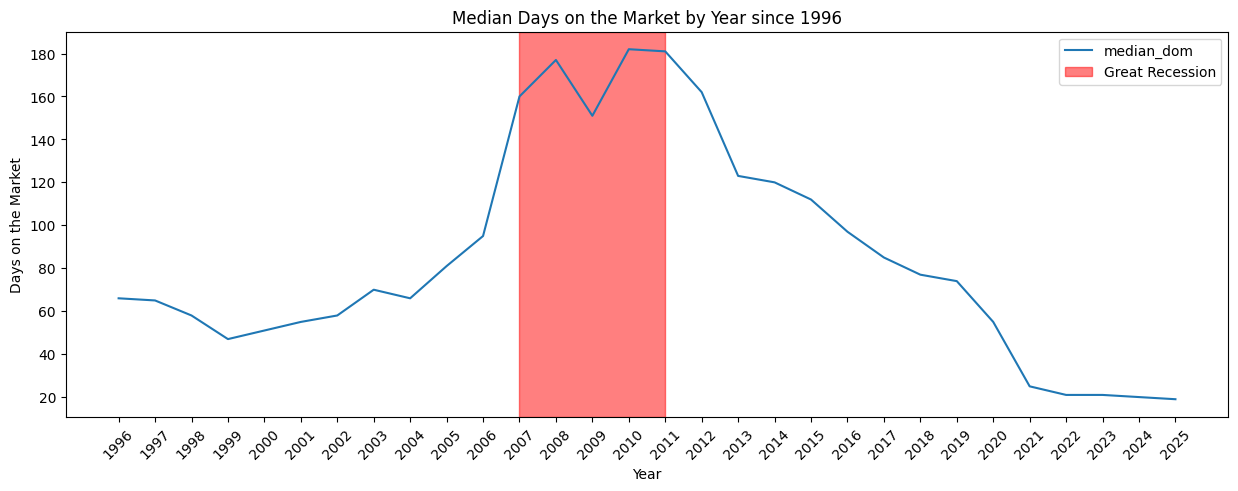

In [ ]:
fig, axs = plt.subplots(figsize=(15,5))

axs.plot('year', 'median_dom', data=med_dom)
axs.set_title('Median Days on the Market by Year since 1996')
axs.set_xlabel('Year')
axs.set_ylabel('Days on the Market')

plt.xticks(range(1996, 2026, 1), rotation=45)
plt.axvspan(2007, 2011, color='red', alpha=0.5, label='Great Recession')
plt.legend()
plt.show()

## Distribution of Days on the Market During the Great Financial Crisis

In [ ]:
query="""
SELECT daysonmarket
FROM gsmls_imputed_data
WHERE listdate BETWEEN '2007-10-01' AND '2009-03-31'
OR closeddate BETWEEN '2007-10-01' AND '2009-03-31';
"""

recession_data = pd.read_sql_query(query, tax_engine)

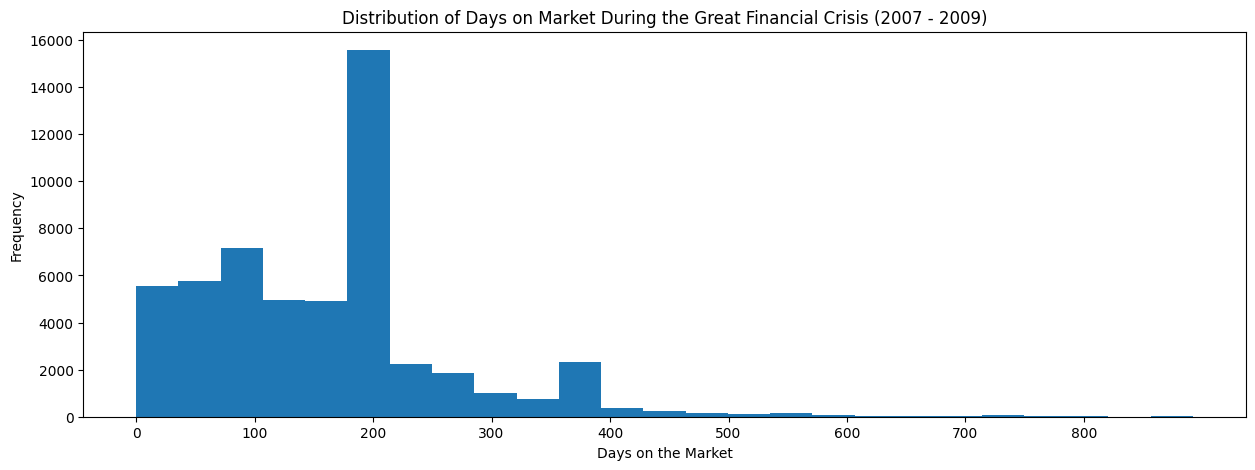

In [ ]:
fig, axs = plt.subplots(figsize=(15,5))

axs.hist('daysonmarket', data=recession_data, bins=25)
axs.set_title('Distribution of Days on Market During the Great Financial Crisis (2007 - 2009)')
axs.set_xlabel('Days on the Market')
axs.set_ylabel('Frequency')

plt.xticks(range(0,900, 100))
plt.show()

## Investment Properties Sold by Year

In [ ]:
query="""
SELECT year, COUNT(investment_sale) as investment_properties_sold
FROM gsmls_imputed_data
WHERE investment_sale = TRUE
GROUP BY year;
"""

investment_data = pd.read_sql_query(query, tax_engine)

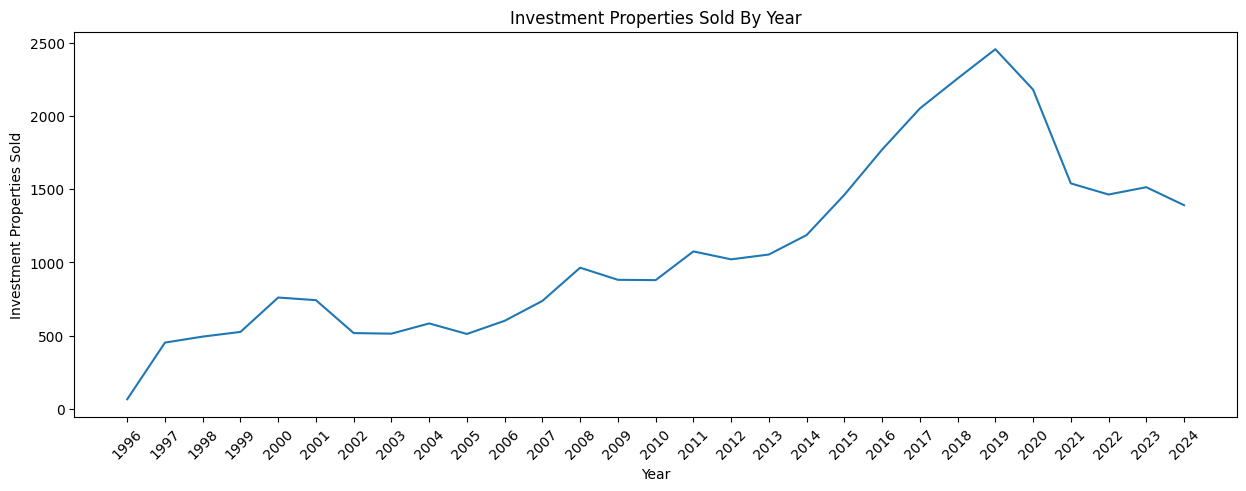

In [ ]:
fig, axs = plt.subplots(figsize=(15,5))

# 2025 data excluded (year is not complete)
axs.plot('year', 'investment_properties_sold', data=investment_data[investment_data['year'] < 2025])
axs.set_title('Investment Properties Sold By Year')
axs.set_xlabel('Year')
axs.set_ylabel('Investment Properties Sold')

plt.xticks(range(1996, 2025, 1), rotation=45)
plt.show()

## For the current Top 10 Municipalities for investment sales, plot their investment totals by year

In [ ]:
query="""
SELECT town, county, year, COUNT(investment_sale) as investment_properties_sold
FROM gsmls_imputed_data
WHERE investment_sale = TRUE AND year = '2024'
GROUP BY town, county, year
ORDER BY investment_properties_sold DESC
LIMIT 10;;
"""

investment_data = pd.read_sql_query(query, tax_engine)

In [ ]:
investment_data

,town,county,year,investment_properties_sold
0,Newark City,Essex,2024,56
1,East Orange City,Essex,2024,39
2,Denville Twp,Morris,2024,33
3,Parsippany-Troy Hills Twp,Morris,2024,30
4,Rockaway Twp,Morris,2024,27
5,Morris Plains Boro,Morris,2024,25
6,Plainfield City,Union,2024,23
7,Hopatcong Boro,Sussex,2024,23
8,Hillsborough Twp,Somerset,2024,23
9,West Milford Twp,Passaic,2024,23


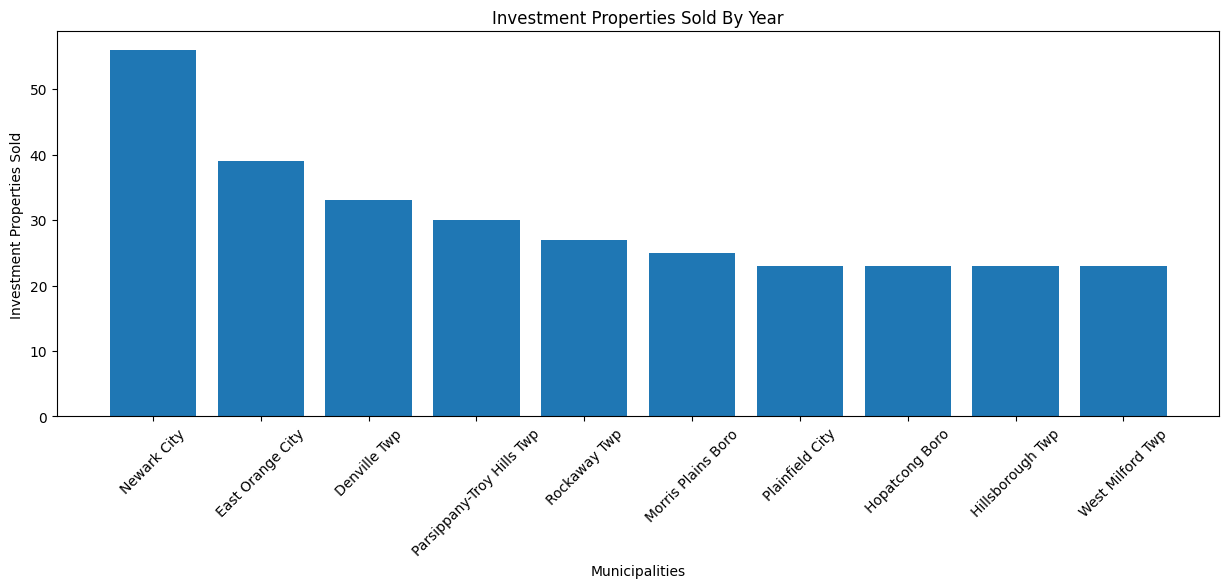

In [ ]:
fig, axs = plt.subplots(figsize=(15,5))

axs.bar('town', 'investment_properties_sold', data=investment_data)
axs.set_title('Investment Properties Sold By Year')
axs.set_xlabel('Municipalities')
axs.set_ylabel('Investment Properties Sold')

plt.xticks(rotation=45)
plt.show()

In [ ]:
query="""
SELECT town, county, year, COUNT(investment_sale) as investment_properties_sold
FROM gsmls_imputed_data
WHERE investment_sale = TRUE AND town IN ('Newark City', 'East Orange City',
'Denville Twp', 'Parsippany-Troy Hills Twp', 'Rockaway Twp', 'Morris Plains Boro',
'Plainfield City', 'Hopatcong Boro', 'Hillsborough Twp', 'West Milford Twp')
AND county IN ('Essex', 'Morris', 'Union', 'Sussex', 'Somerset', 'Passaic')
GROUP BY town, county, year
ORDER BY year;
"""

investment_data = pd.read_sql_query(query, tax_engine)

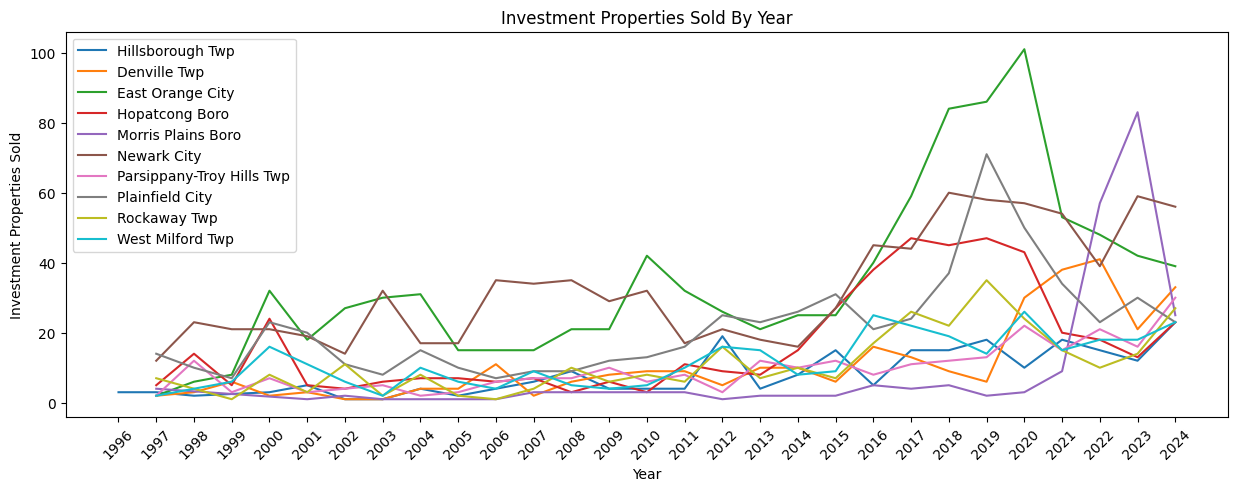

In [ ]:
fig, axs = plt.subplots(figsize=(15,5))

for i in investment_data['town'].unique():

  # 2025 data excluded (year is not complete)
  axs.plot('year', 'investment_properties_sold', data=investment_data[(investment_data['town'] == i) & (investment_data['year'] < 2025)], label=i)

axs.set_title('Investment Properties Sold By Year')
axs.set_xlabel('Year')
axs.set_ylabel('Investment Properties Sold')

plt.xticks(range(1996, 2025, 1), rotation=45)
plt.legend()
plt.show()

## Scatterplot of Investment Totals vs Median Sales Price

#### Determine if there's a correlation between the median sales price and the amount of investing going on in that municipality

In [ ]:
query="""
SELECT gsmls_imputed_data.town, gsmls_imputed_data.county, gsmls_imputed_data.year, percentile_cont(0.5) WITHIN GROUP(ORDER BY CAST(salesprice as numeric)) as median_sales_price, investment_table.investment_properties_sold
FROM gsmls_imputed_data
LEFT JOIN(
  SELECT town, county, year, COUNT(investment_sale) as investment_properties_sold
  FROM gsmls_imputed_data
  WHERE investment_sale = TRUE and year = '2024'
  GROUP BY town, county, year
) as investment_table
ON investment_table.town = gsmls_imputed_data.town AND investment_table.county = gsmls_imputed_data.county AND investment_table.year = gsmls_imputed_data.year
WHERE gsmls_imputed_data.year = '2024'
GROUP BY gsmls_imputed_data.town, gsmls_imputed_data.county, gsmls_imputed_data.year, investment_table.investment_properties_sold;
"""

investment_data = pd.read_sql_query(query, tax_engine)

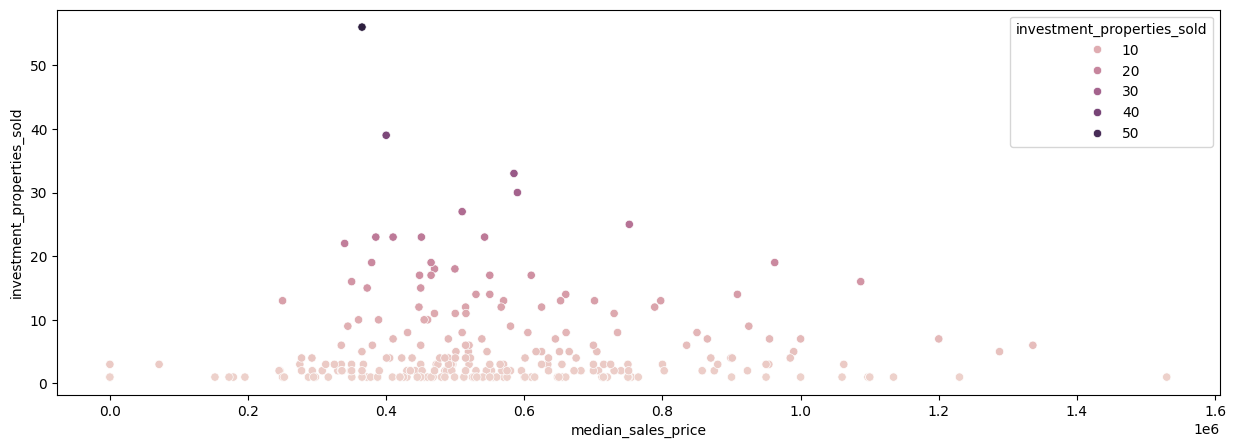

In [ ]:
fig, axs = plt.subplots(figsize=(15,5))

sns.scatterplot(data=investment_data, x='median_sales_price', y='investment_properties_sold', hue='investment_properties_sold')
plt.show()

In [ ]:
query="""
SELECT gsmls_imputed_data.year, percentile_cont(0.5) WITHIN GROUP(ORDER BY CAST(salesprice as numeric)) as median_sales_price, investment_table.investment_properties_sold
FROM gsmls_imputed_data
LEFT JOIN(
  SELECT year, COUNT(investment_sale) as investment_properties_sold
  FROM gsmls_imputed_data
  WHERE investment_sale = TRUE
  GROUP BY year
) as investment_table
ON investment_table.year = gsmls_imputed_data.year
GROUP BY gsmls_imputed_data.year, investment_table.investment_properties_sold;
"""

investment_data = pd.read_sql_query(query, tax_engine)

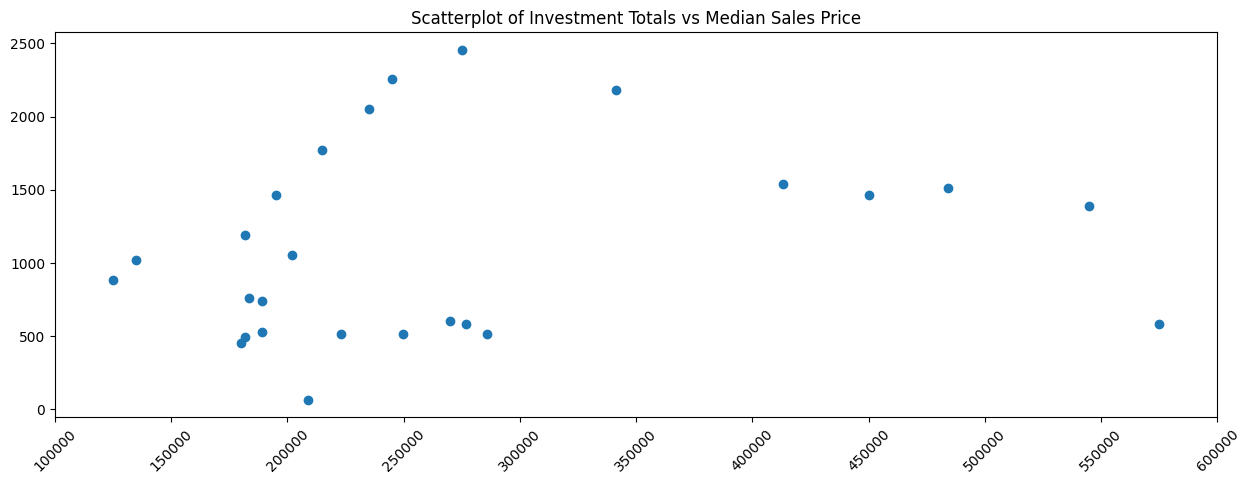

In [ ]:
fig, axs = plt.subplots(figsize=(15,5))

axs.scatter(x='median_sales_price', y='investment_properties_sold', data=investment_data[investment_data['median_sales_price'] > 0])
axs.set_title('Scatterplot of Investment Totals vs Median Sales Price')

plt.xticks(range(100000, 650000, 50000), rotation=45)
plt.show()

# Plot the Amount of Bank Owned Propeerties were Sold by Year

In [ ]:
query="""
SELECT year, COUNT(bank_owned) as bank_properties_sold
FROM gsmls_imputed_data
WHERE bank_owned = TRUE
GROUP BY year;
"""

bank_owned_data = pd.read_sql_query(query, tax_engine)

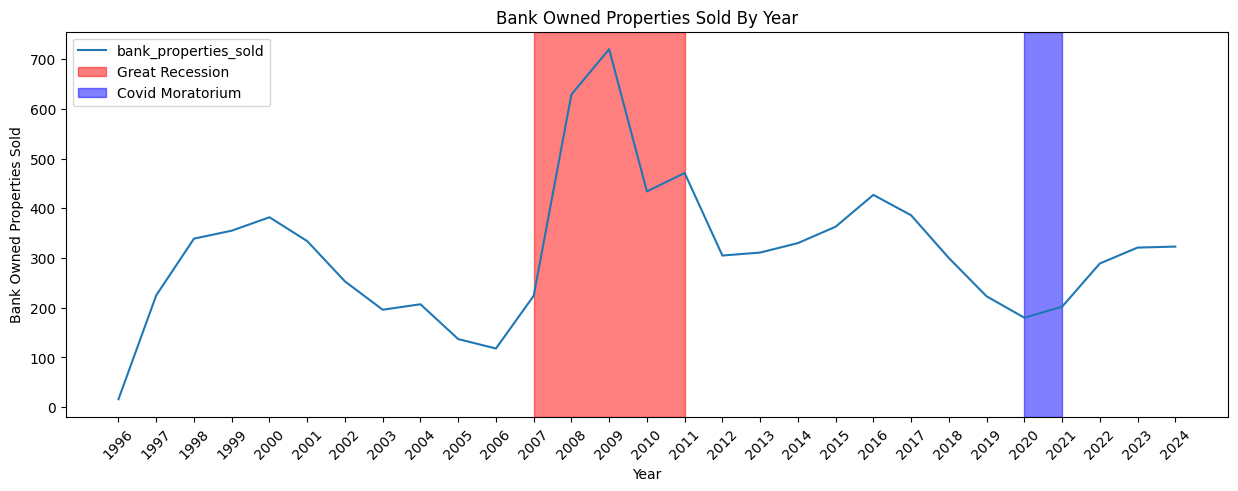

In [ ]:
fig, axs = plt.subplots(figsize=(15,5))

axs.plot('year', 'bank_properties_sold', data=bank_owned_data[bank_owned_data['year'] < 2025])
axs.set_title('Bank Owned Properties Sold By Year')
axs.set_xlabel('Year')
axs.set_ylabel('Bank Owned Properties Sold')

plt.axvspan(2007, 2011, color='red', alpha=0.5, label='Great Recession')
plt.axvspan(2020, 2021, color='blue', alpha=0.5, label='Covid Moratorium')
plt.xticks(range(1996, 2025, 1), rotation=45)
plt.legend()
plt.show()

In [ ]:
query="""
SELECT town, county, year, COUNT(bank_owned) as bank_properties_sold
FROM gsmls_imputed_data
WHERE bank_owned = TRUE AND year BETWEEN '2018' AND '2025'
GROUP BY town, county, year
ORDER BY bank_properties_sold DESC
LIMIT 10;;
"""

bank_owned_data = pd.read_sql_query(query, tax_engine)

In [ ]:
bank_owned_data.head(10)

,town,county,year,bank_properties_sold
0,Jefferson Twp,Morris,2019,10
1,Bridgewater Twp,Somerset,2022,10
2,Rahway City,Union,2022,9
3,Manville Boro,Somerset,2022,9
4,Union Twp,Union,2024,9
5,Hopatcong Boro,Sussex,2019,8
6,Clifton City,Passaic,2023,8
7,Hopatcong Boro,Sussex,2023,8
8,Parsippany-Troy Hills Twp,Morris,2023,8
9,Vernon Twp,Sussex,2018,8


In [ ]:
query="""
SELECT year, percentile_cont(0.5) WITHIN GROUP(ORDER BY year_built) as med_year_built
FROM gsmls_imputed_data
WHERE status_short = 'SD'
GROUP BY year
ORDER BY year;
"""

year_built_data = pd.read_sql_query(query, tax_engine)

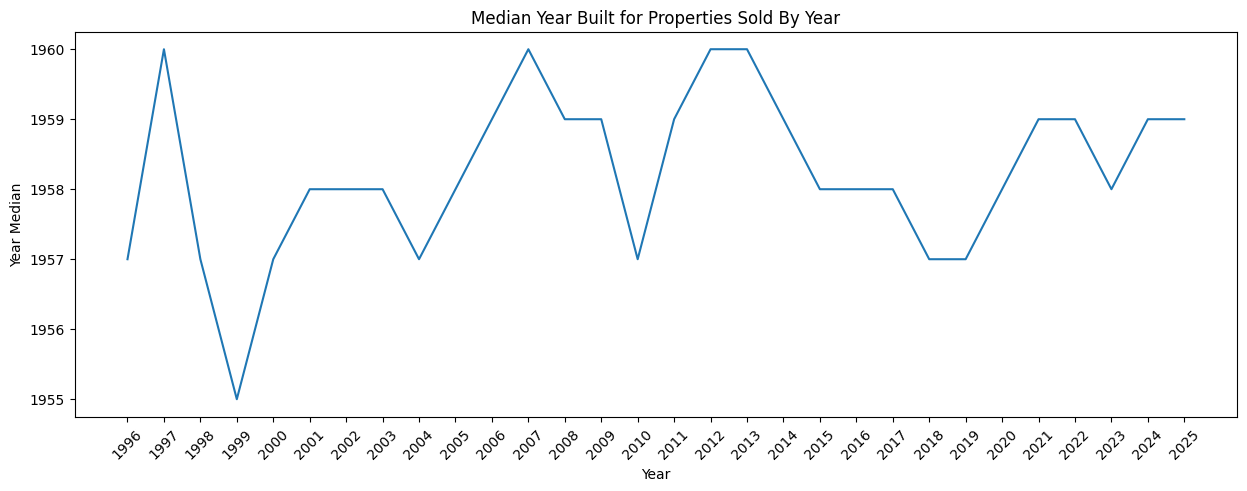

In [ ]:
fig, axs = plt.subplots(figsize=(15,5))

axs.plot('year', 'med_year_built', data=year_built_data)
axs.set_title('Median Year Built for Properties Sold By Year')
axs.set_xlabel('Year')
axs.set_ylabel('Year Median')

plt.xticks(range(1996, 2026, 1), rotation=45)
plt.show()

In [ ]:
query="""
SELECT year_built, COUNT(year_built) as year_built_count
FROM gsmls_imputed_data
WHERE status_short = 'SD'
GROUP BY year_built
ORDER BY year_built;
"""

year_built_data = pd.read_sql_query(query, tax_engine)
year_built_data = year_built_data[(year_built_data['year_built'] >= 1850) & (year_built_data['year_built'] < 2025)]

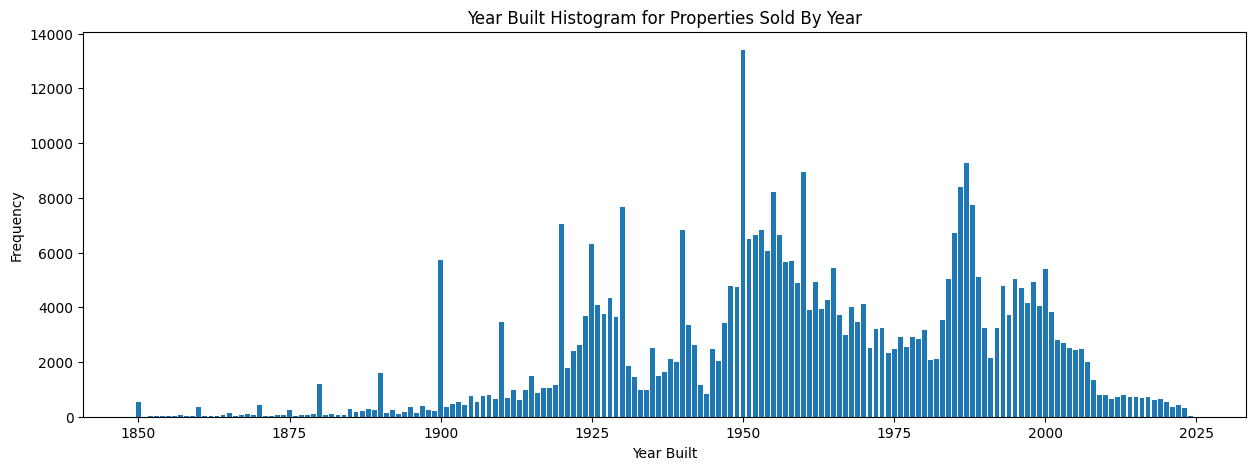

In [ ]:
fig, axs = plt.subplots(figsize=(15,5))

axs.bar('year_built', 'year_built_count', data=year_built_data)
axs.set_title('Year Built Histogram for Properties Sold By Year')
axs.set_xlabel('Year Built')
axs.set_ylabel('Frequency')

plt.show()

In [ ]:
conn2 = psycopg2.connect(dbname="gsmls", user="postgres",
                        password="Xy14RNw02SmD",
                        host="database-1.chuq28s6itob.us-east-2.rds.amazonaws.com",
                        port="5432")
cursor2 = conn2.cursor()

In [ ]:
query = """
SELECT table_name
FROM information_schema.tables
WHERE table_schema = 'public';
"""

cursor2.execute(query)

In [ ]:
cursor2.fetchall()

[('res_properties',),
 ('mul_properties',),
 ('lnd_properties',),
 ('rnt_properties',),
 ('gsmls_event_log',),
 ('tax_properties',)]

In [ ]:
query = f"SELECT * FROM res_properties LIMIT 1;"
test_data = pd.read_sql_query(query, gsmls_engine)

In [ ]:
test_data.columns[:100]

Index(['MLSNUM', 'MLS', 'STATUS_SHORT', 'STREETNUMDISPLAY', 'STREETNAME',
       'TOWN', 'COUNTY', 'ZIPCODE', 'TOWNCODE', 'COUNTYCODE', 'BLOCKID',
       'LOTID', 'TAXID', 'LATITUDE', 'LONGITUDE', 'DAYSONMARKET', 'CONDITION',
       'ORIGLISTPRICE', 'LISTPRICE', 'OLP/LP%', 'SALESPRICE', 'SP/LP%',
       'SP/OLP%', 'INVESTMENT_SALE', 'POTENTIAL_INVESTMENT', 'DISTRESSED_SALE',
       'SHORT_SALE', 'BANK_OWNED', 'LOANTERMS_SHORT', 'ROOMS', 'BEDS',
       'BATHSFULLTOTAL', 'BATHSHALFTOTAL', 'BATHSTOTAL', 'SQFTAPPROX',
       'LOTSIZE', 'LOTSIZE (SQFT)', 'ASSESSAMOUNTBLDG', 'ASSESSAMOUNTLAND',
       'ASSESSTOTAL', 'TAXAMOUNT', 'SUBPROPTYPE_SFH', 'STYLEPRIMARY_SHORT',
       'QTR', 'MONTH', 'YEAR', 'SUBDIVISION', 'DAYS_TO_CLOSE',
       'ANTIC_CLOSEDATE_DIFF', 'YEARBUILT', 'LISTDATE', 'PENDINGDATE',
       'ANTICCLOSEDDATE', 'CLOSEDDATE', 'EXPIREDATE', 'WITHDRAWNDATE',
       'OWNERSHIP_SHORT', 'EASEMENT_SHORT', 'PARKNBRAVAIL', 'GARAGECAP',
       'FIREPLACES', 'POOL_SHORT', 'FLOODZONE', 'Z

In [ ]:
[i for i in test_data.columns if '_FLOORS' in i]

['WOOD_FLOORS',
 'MARBLE_FLOORS',
 'TILE_FLOORS',
 'CARPET_FLOORS',
 'VINYL_FLOORS',
 'LAMINATE_FLOORS',
 'STONE_FLOORS',
 'PARQUET_FLOORS']

### Create a pie chart displaying the percentage of flooring types used in all homes currently sold to date

In [ ]:
# Iterate over the list of flooring types to create a new table with all flooring types
#used in sold properties

data_list = []

for i in [i[:-7] for i in test_data.columns if '_FLOORS' in i]:

  query=f"""
  SELECT \"YEAR\", COUNT(\"{i}_FLOORS\") as {i.lower()}
  FROM  res_properties
  WHERE \"STATUS_SHORT\" = 'SD' AND \"{i}_FLOORS\" IS TRUE
  GROUP BY \"YEAR\"
  ORDER BY \"YEAR\"
  """

  floor_data = pd.read_sql_query(query, gsmls_engine)
  # Calculate the percentage change in the use of flooring compared to the prior year
  floor_data[f'{i.lower()}_pct_change'] = (floor_data[f'{i.lower()}'].pct_change() * 100).round(2)

  data_list.append(floor_data)

In [ ]:
# Use the dataframe in index 0 to merge all dataframes to

total_data = data_list[0]

for i in data_list[1:]:

  total_data = total_data.merge(i, on='YEAR')

In [ ]:
# Remove the percentage change columns and transpose the dataframe
# to make the columns as years and the index the flooring types
new_df = total_data[[i for i in total_data.columns if 'pct' not in i]]
new_df = new_df.T

In [ ]:
# Drop the row which represents the year
new_df.drop(new_df.index[0], inplace=True)

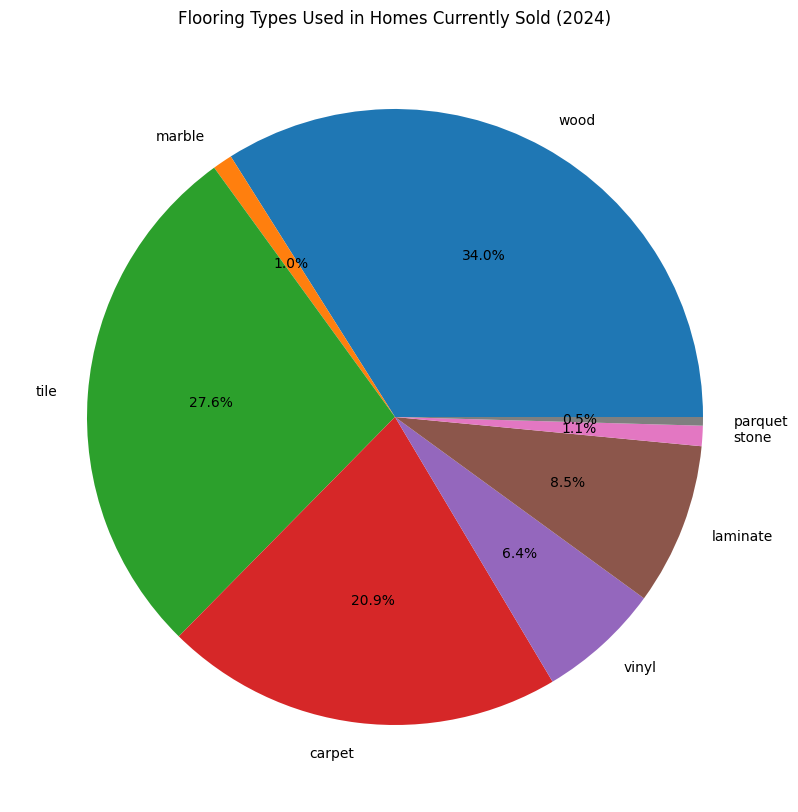

In [ ]:
fig, ax = plt.subplots(figsize=(10, 10))
ax.pie(new_df[16], labels=new_df.index, autopct='%1.1f%%')
ax.set_title('Flooring Types Used in Homes Currently Sold (2024)')
plt.show()

In [ ]:
total_data

,YEAR,wood,wood_pct_change,marble,marble_pct_change,tile,tile_pct_change,carpet,carpet_pct_change,vinyl,vinyl_pct_change,laminate,laminate_pct_change,stone,stone_pct_change,parquet,parquet_pct_change
0,2008,10546,29.11,562,24.61,3387,31.59,10042,25.42,3295,13.50,155,NaN,375,40.98,377,46.69
1,2009,9804,-7.04,527,-6.23,3162,-6.64,9232,-8.07,2998,-9.01,832,436.77,320,-14.67,258,-31.56
2,2010,6070,-38.09,416,-21.06,1954,-38.20,5207,-43.60,1394,-53.50,495,-40.50,241,-24.69,152,-41.09
3,2011,9873,62.65,504,21.15,3427,75.38,8600,65.16,2270,62.84,923,86.46,345,43.15,237,55.92
4,2012,11105,12.48,596,18.25,4001,16.75,9530,10.81,2459,8.33,1113,20.59,399,15.65,254,7.17
5,2013,24290,118.73,1337,124.33,8970,124.19,20250,112.49,5115,108.01,2649,138.01,922,131.08,498,96.06
6,2014,23249,-4.29,1136,-15.03,9055,0.95,18881,-6.76,4466,-12.69,2708,2.23,966,4.77,396,-20.48
7,2015,24727,6.36,1267,11.53,9884,9.16,19402,2.76,4398,-1.52,3072,13.44,995,3.00,520,31.31
8,2016,29367,18.76,1446,14.13,11862,20.01,22913,18.10,4886,11.10,4074,32.62,938,-5.73,516,-0.77
9,2017,25400,-13.51,1174,-18.81,10980,-7.44,19098,-16.65,3968,-18.79,3524,-13.50,914,-2.56,412,-20.16
